In [1]:
# =========================
# Plotting utilities
# =========================

from pathlib import Path
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from transformer_lens.utils import to_numpy

# 📁 Create plots folder (script-safe + notebook-safe)
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

PLOTS_DIR = BASE_DIR / "overleaf" / "nopos_icml_2026" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def _safe_filename(title: str, fallback: str):
    if title:
        return title.lower().replace(" ", "_").replace("/", "_")
    return fallback


def line(
    tensor,
    line_labels=None,
    yaxis="",
    xaxis="",
    title="",
    legend_title="",
    show_legend=False,
    export=False,
    file_name=None,
    save_png=True,
    save_pdf=False,
    save_svg=False,
    save_html=False,
    dpi=300,
    **kwargs,
):
    tensor = to_numpy(tensor)

    fig = px.line(tensor, template="plotly_white", **kwargs)

    fig.update_layout(
        title=dict(text=title, font=dict(size=24, family="Serif")),
        xaxis=dict(title=xaxis, title_font=dict(size=18), tickfont=dict(size=16)),
        yaxis=dict(title=yaxis, title_font=dict(size=18), tickfont=dict(size=16)),
        legend=dict(title=legend_title, font=dict(size=16)),
        showlegend=show_legend,
        width=800,
        height=500,
        margin=dict(l=50, r=50, t=80, b=50),
    )

    for trace in fig.data:
        trace.line.width = 3
        trace.marker = dict(symbol="circle", size=8)
        trace.showlegend = show_legend

    if line_labels:
        for i, label in enumerate(line_labels):
            fig.data[i].name = label

    # =========================
    # Export
    # =========================
    if export:
        if file_name:
            base = PLOTS_DIR / file_name
        else:
            fname = _safe_filename(title, "line_plot")
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            base = PLOTS_DIR / f"{fname}_{timestamp}"

        if save_png:
            fig.write_image(f"{base}.png", scale=dpi / 100)
        if save_pdf:
            fig.write_image(f"{base}.pdf")
        if save_svg:
            fig.write_image(f"{base}.svg")
        if save_html:
            fig.write_html(f"{base}.html")

    fig.show()


def imshow(
    tensor,
    yaxis="",
    xaxis="",
    title="Image",
    export=False,
    file_name=None,
    save_png=True,
    save_pdf=False,
    save_svg=False,
    save_html=False,
    dpi=300,
    col_markers=None,
    **kwargs,
):
    tensor = to_numpy(tensor)

    fig = px.imshow(
        tensor,
        color_continuous_scale="RdBu_r",
        color_continuous_midpoint=0.0,
        labels={"x": xaxis, "y": yaxis},
        template="plotly_white",
        aspect="equal",
        **kwargs,
    )

    fig.update_layout(
        title=dict(text=title, font=dict(size=24, family="Serif")),
        xaxis=dict(title=xaxis, title_font=dict(size=18), tickfont=dict(size=16)),
        yaxis=dict(title=yaxis, title_font=dict(size=18), tickfont=dict(size=16)),
        width=800,
        height=600,
        margin=dict(l=50, r=50, t=80, b=50),
    )

    if col_markers:
        y_marker = -0.6
        for item in col_markers:
            if isinstance(item, (int, float)):
                x, label, color = item, None, '#C44E52'
            else:
                x, label, color = item
            fig.add_trace(
                go.Scatter(
                    x=[x],
                    y=[y_marker],
                    mode='markers',
                    marker=dict(
                        symbol='triangle-down',
                        size=10,
                        color=color,
                        line=dict(color='black', width=0.5),
                    ),
                    showlegend=False,
                    cliponaxis=False,
                )
            )
            if label:
                fig.add_annotation(
                    x=x,
                    y=y_marker - 0.9,
                    text=label,
                    showarrow=False,
                    font=dict(size=12, color=color),
                )
        fig.update_yaxes(range=[tensor.shape[0] - 0.5, -2.2])

    # =========================
    # Export
    # =========================
    if export:
        if file_name:
            base = PLOTS_DIR / file_name
        else:
            fname = _safe_filename(title, "imshow")
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            base = PLOTS_DIR / f"{fname}_{timestamp}"

        if save_png:
            fig.write_image(f"{base}.png", scale=dpi / 100)
        if save_pdf:
            fig.write_image(f"{base}.pdf")
        if save_svg:
            fig.write_image(f"{base}.svg")
        if save_html:
            fig.write_html(f"{base}.html")

    fig.show()


Model loaded. Variables available:
 - x_i: Input to block2 attention (post-LN1) [T, n_embd]
 - q_i: Queries for Head 7 [T, head_dim]
 - k_i: Keys for Head 7 [T, head_dim]
 - W_Q, W_K, b_Q, b_K: Weights/Biases for Head 7


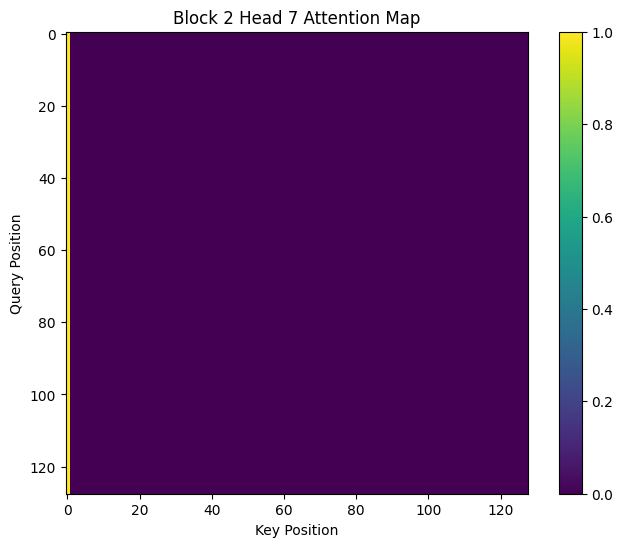

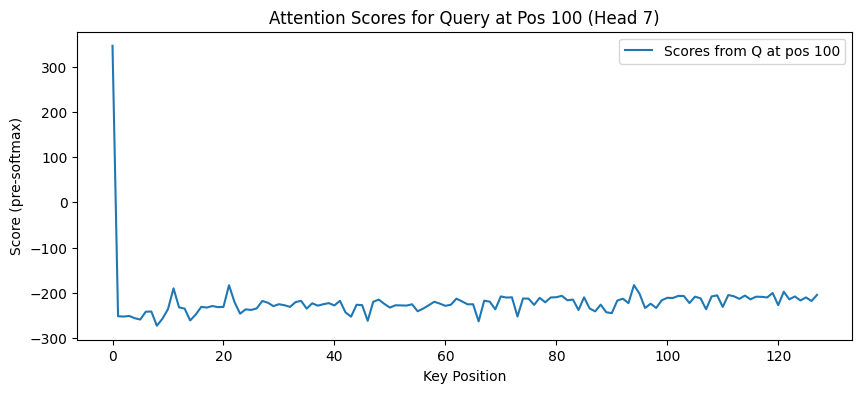

Score at Pos 0: 346.23
Score at Pos 80: -209.93
Mean score (other pos): -230.29


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from typing import Literal

# Configuration
checkpoint_path = "nanoGPT/out-2layer-mechanism-bos80/R0/final_ckpt.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"
pos0_head_idx = 7
bos_pos = 80

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True
    use_positional_embedding: bool = False
    norm_type: Literal["layernorm", "rmsnorm"] = "layernorm"
    log_attention_stats: bool = False
    skip_ln2: bool = False

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        
        self.last_q = q
        self.last_k = k
        
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        att = att.masked_fill(mask[:,:,:T,:T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        self.last_attn = att # Store for visualization
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.c_proj(y)
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class CustomModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)
        self.block1 = Block(config)
        self.block2 = Block(config)
        self.ln_f = LayerNorm(config.n_embd, config.bias)
    def forward(self, idx):
        x = self.wte(idx)
        x = self.block1(x)
        # Capture input to block2's attention (post LN1)
        self.block2_input_ln1 = self.block2.ln_1(x)
        x = self.block2(x)
        x = self.ln_f(x)
        return x

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
config_dict = checkpoint['config']
gpt_conf = GPTConfig(
    n_layer=2,
    n_head=config_dict['n_head'],
    n_embd=config_dict['n_embd'],
    block_size=config_dict['block_size'],
    vocab_size=config_dict['vocab_size'],
    bias=config_dict.get('bias', True)
)

# Initialize and load model
model = CustomModel(gpt_conf)
state_dict = checkpoint['model']
model_state_dict = model.state_dict()
new_state_dict = {k: v for k, v in state_dict.items() if k in model_state_dict}
model.load_state_dict(new_state_dict, strict=False)
model.to(device)
model.eval()

# Extract weights for head 7
layer = model.block2
n_head = gpt_conf.n_head
head_dim = gpt_conf.n_embd // n_head
c_attn_weight = layer.attn.c_attn.weight
c_attn_bias = layer.attn.c_attn.bias
W_Q_all, W_K_all, W_V_all = c_attn_weight.split(gpt_conf.n_embd, dim=0)
b_Q_all, b_K_all, b_V_all = c_attn_bias.split(gpt_conf.n_embd, dim=0)
W_Q = W_Q_all.view(n_head, head_dim, gpt_conf.n_embd)[pos0_head_idx]
W_K = W_K_all.view(n_head, head_dim, gpt_conf.n_embd)[pos0_head_idx]
b_Q = b_Q_all.view(n_head, head_dim)[pos0_head_idx]
b_K = b_K_all.view(n_head, head_dim)[pos0_head_idx]

# Perform forward pass
tokens = torch.randint(0, gpt_conf.vocab_size, (1, gpt_conf.block_size), device=device)
with torch.no_grad():
    _ = model(tokens)

# Get activations
x_i = model.block2_input_ln1[0] # [T, n_embd]
q_i = model.block2.attn.last_q[0, pos0_head_idx] # [T, head_dim]
k_i = model.block2.attn.last_k[0, pos0_head_idx] # [T, head_dim]

print(f"Model loaded. Variables available:")
print(f" - x_i: Input to block2 attention (post-LN1) [T, n_embd]")
print(f" - q_i: Queries for Head {pos0_head_idx} [T, head_dim]")
print(f" - k_i: Keys for Head {pos0_head_idx} [T, head_dim]")
print(f" - W_Q, W_K, b_Q, b_K: Weights/Biases for Head {pos0_head_idx}")

# Validation Plot: Attention
attn_weights = model.block2.attn.last_attn[0, pos0_head_idx].cpu().numpy()
plt.figure(figsize=(8, 6))
plt.imshow(attn_weights, cmap='viridis')
plt.title(f'Block 2 Head {pos0_head_idx} Attention Map')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.colorbar()
plt.show()

# Dot Product Investigation
scores = (q_i @ k_i.T) / math.sqrt(head_dim)
scores = scores.cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(scores[100, :], label='Scores from Q at pos 100')
plt.title(f'Attention Scores for Query at Pos 100 (Head {pos0_head_idx})')
plt.xlabel('Key Position')
plt.ylabel('Score (pre-softmax)')
plt.legend()
plt.show()

print(f"Score at Pos 0: {scores[100, 0]:.2f}")
print(f"Score at Pos 80: {scores[100, 80]:.2f}")
print(f"Mean score (other pos): {np.mean(scores[100, 1:80]):.2f}")


In [3]:
line(k_i.T.mean(0), title='Average Neuron Activation for Key'), line(q_i.mean(0), title='Average Neuron Activation for Query')

(None, None)

In [4]:
imshow(q_i@k_i.T, title='<Query, Key> 0-attending head before softmax')

In [5]:
imshow(F.softmax(q_i@k_i.T), title='<Query, Key> 0-attending head after softmax')

/home/nlp/matan_avitan/.tmp/ipykernel_2892242/3920015487.py:1: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



In [6]:
imshow(b_K.unsqueeze(0))

In [7]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'Path', 'datetime', 'px', 'go', 'to_numpy', 'BASE_DIR', 'PLOTS_DIR', '_safe_filename', 'line', 'imshow', '_i2', 'torch', 'nn', 'F', 'math', 'plt', 'np', 'dataclass', 'Literal', 'checkpoint_path', 'device', 'pos0_head_idx', 'bos_pos', 'GPTConfig', 'LayerNorm', 'CausalSelfAttention', 'MLP', 'Block', 'CustomModel', 'checkpoint', 'config_dict', 'gpt_conf', 'model', 'state_dict', 'model_state_dict', 'new_state_dict', 'layer', 'n_head', 'head_dim', 'c_attn_weight', 'c_attn_bias', 'W_Q_all', 'W_K_all', 'W_V_all', 'b_Q_all', 'b_K_all', 'b_V_all', 'W_Q', 'W_K', 'b_Q', 'b_K', 'tokens', 'x_i', 'q_i', 'k_i', 'attn_weights', 'scores', '_i3', '_3', '_i4', '_i5', '_i6', '_i7'])

In [8]:
line(np.linalg.norm((x_i@W_K.T).detach().cpu().numpy(), axis=0))

In [9]:
kt=x_i@W_K.T
qt=x_i@W_Q.T
imshow(qt@kt.T)

In [10]:
line(np.linalg.norm(np.array(W_K.T.detach().cpu()), axis=0))

/home/nlp/matan_avitan/.tmp/ipykernel_2892242/2331747722.py:1: DeprecationWarning:

__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword



In [11]:
imshow(W_K)

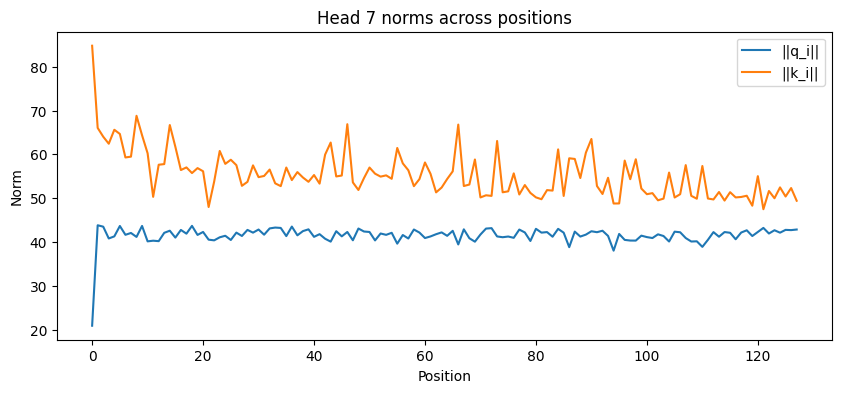

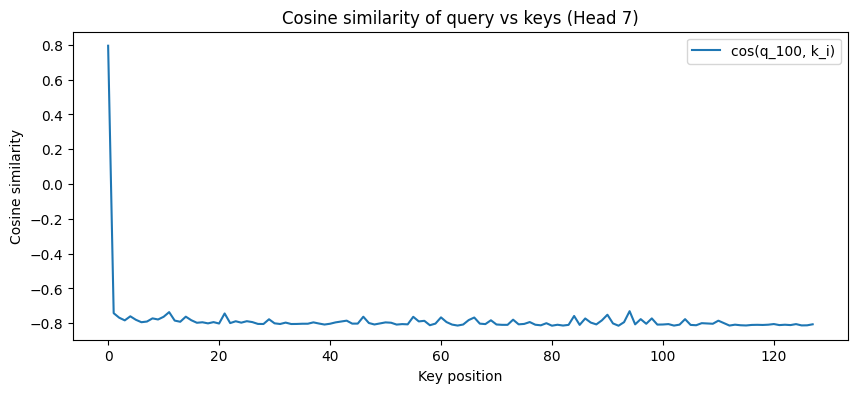

cos(q_100, k_0) = 0.7945
cos(q_100, k_80) = -0.8138
mean cos (other) = -0.7947


In [12]:
# Norms of q_i and k_i
q_norms = torch.norm(q_i, dim=-1).detach().cpu().numpy()
k_norms = torch.norm(k_i, dim=-1).detach().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(q_norms, label="||q_i||")
plt.plot(k_norms, label="||k_i||")
plt.title("Head 7 norms across positions")
plt.xlabel("Position")
plt.ylabel("Norm")
plt.legend()
plt.show()

# Cosine similarity between a query and all keys
query_pos = 100
q_vec = q_i[query_pos]
k_norms_t = torch.norm(k_i, dim=-1)
cos_scores = (q_vec @ k_i.T) / (torch.norm(q_vec) * k_norms_t)
cos_scores = cos_scores.detach().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(cos_scores, label=f"cos(q_{query_pos}, k_i)")
plt.title("Cosine similarity of query vs keys (Head 7)")
plt.xlabel("Key position")
plt.ylabel("Cosine similarity")
plt.legend()
plt.show()

print(f"cos(q_{query_pos}, k_0) = {cos_scores[0]:.4f}")
print(f"cos(q_{query_pos}, k_{bos_pos}) = {cos_scores[bos_pos]:.4f}")
print(f"mean cos (other) = {cos_scores[1:].mean():.4f}")


Top singular values: [16.517326    5.5378284   1.4849079   1.1039798   0.66821676  0.60305023
  0.52406836  0.4417794   0.3477311   0.30978298]
s1/s2 = 2.98


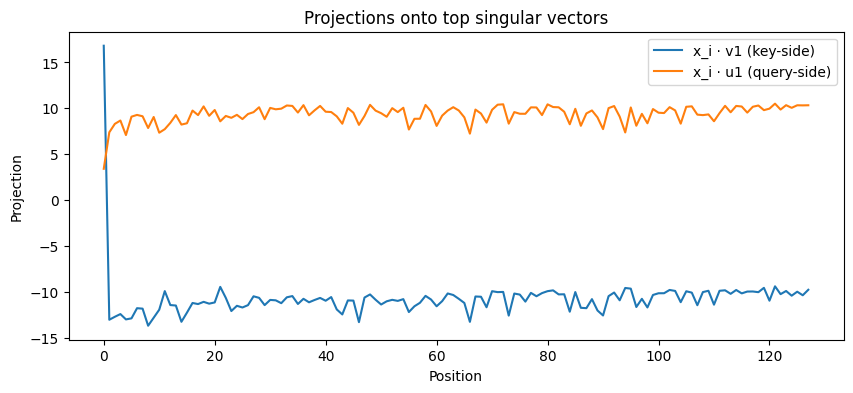

Proj at pos0: k-side 16.82, q-side 3.43


In [13]:
# SVD of W_Q^T W_K to test for low-rank dominance
M = (W_Q.T @ W_K).detach().cpu()
U, S, Vh = torch.linalg.svd(M)
print("Top singular values:", S[:10].numpy())
print(f"s1/s2 = {(S[0] / S[1]).item():.2f}")

x_cpu = x_i.detach().cpu()
v1 = Vh.T[:, 0]
u1 = U[:, 0]
proj_k = (x_cpu @ v1).numpy()
proj_q = (x_cpu @ u1).numpy()

plt.figure(figsize=(10, 4))
plt.plot(proj_k, label="x_i · v1 (key-side)")
plt.plot(proj_q, label="x_i · u1 (query-side)")
plt.title("Projections onto top singular vectors")
plt.xlabel("Position")
plt.ylabel("Projection")
plt.legend()
plt.show()

print(f"Proj at pos0: k-side {proj_k[0]:.2f}, q-side {proj_q[0]:.2f}")


/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:82: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:84: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




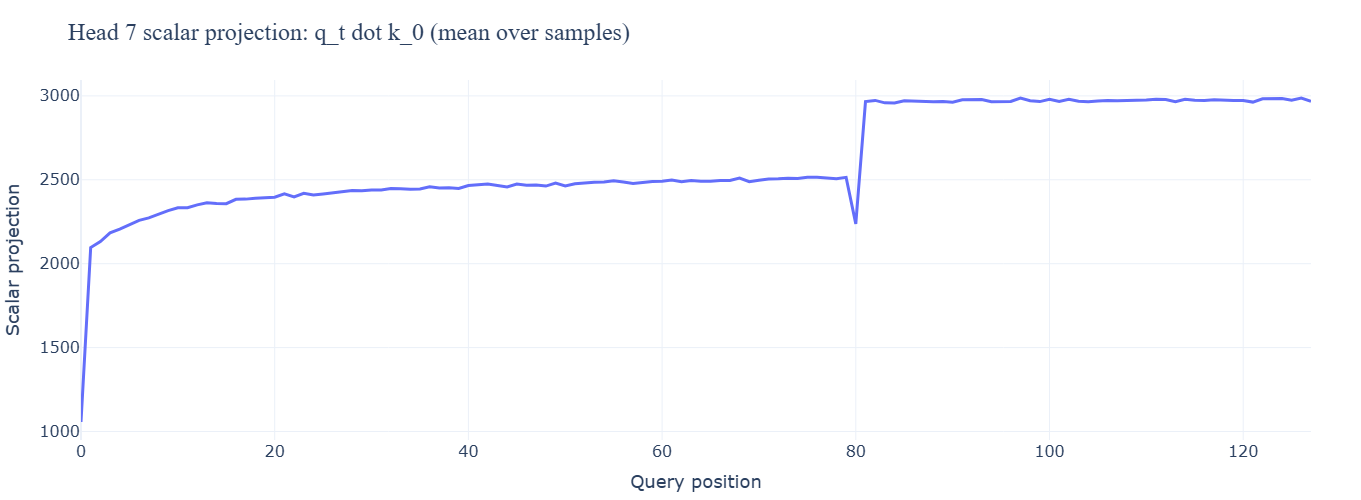

/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:173: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:175: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




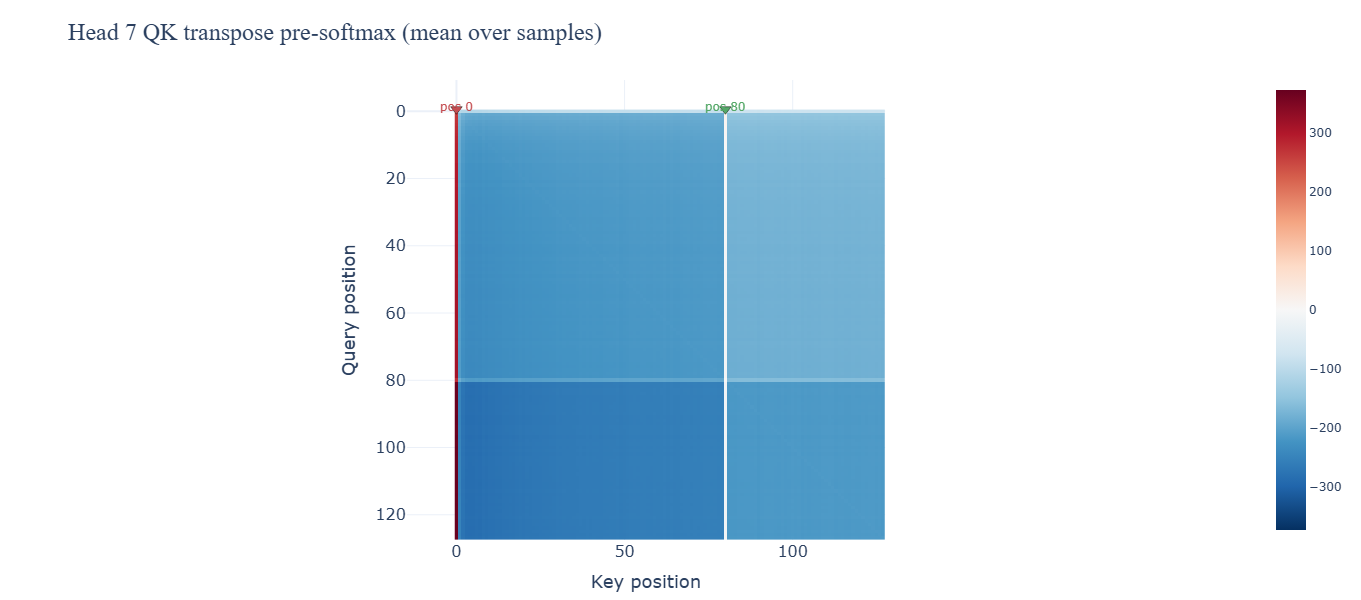

/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:173: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:175: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




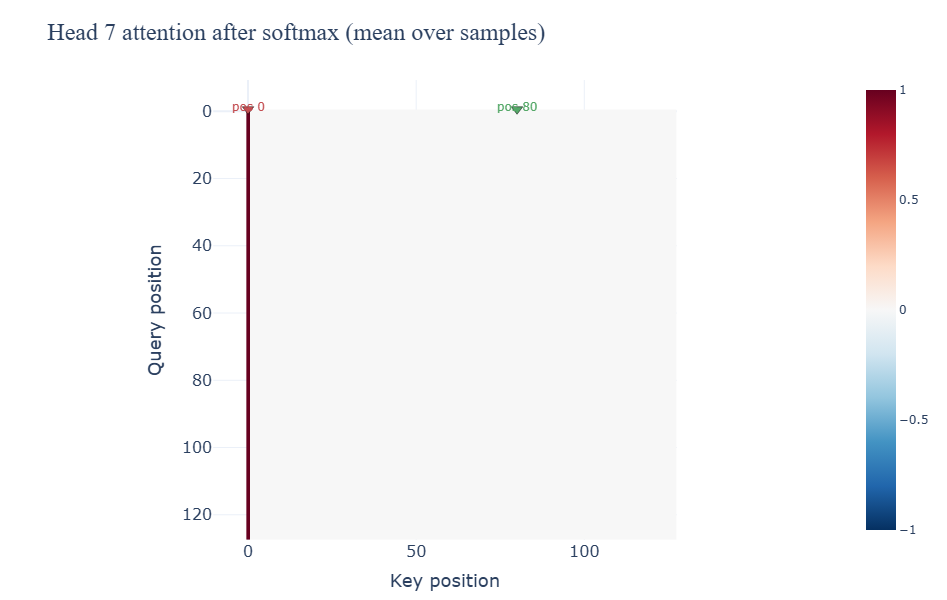

/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:82: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/home/nlp/matan_avitan/.tmp/ipykernel_2892242/472457298.py:84: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




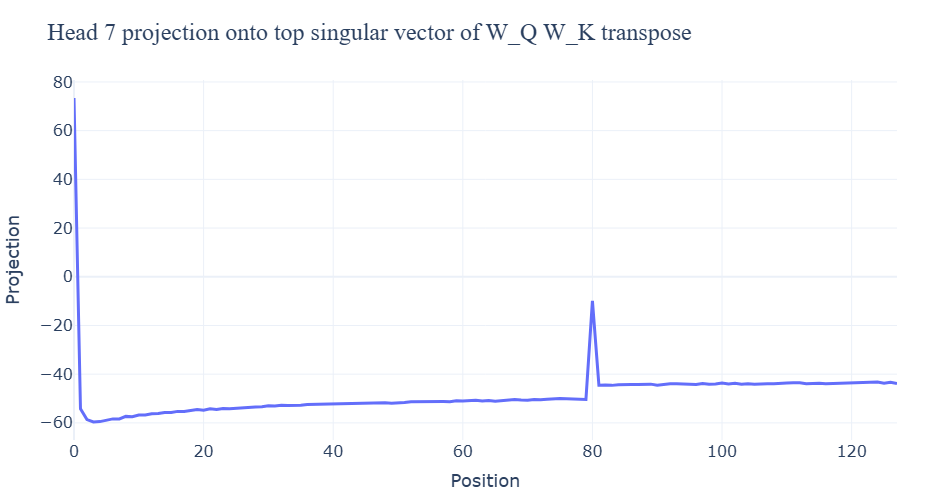

All plots generated and exported.


In [14]:
# ==========================================
# Comprehensive Analysis & Plot Generation
# ==========================================

torch.manual_seed(42)
np.random.seed(42)

n_samples = 512
BOS_TOKEN_ID = 50256

tokens = torch.randint(0, gpt_conf.vocab_size, (n_samples, gpt_conf.block_size), device=device)
tokens[:, bos_pos] = BOS_TOKEN_ID
with torch.no_grad():
    _ = model(tokens)

q = model.block2.attn.last_q[:, pos0_head_idx]  # [B, T, head_dim]
k = model.block2.attn.last_k[:, pos0_head_idx]  # [B, T, head_dim]
x_ln = model.block2_input_ln1  # [B, T, n_embd]

# 1. Average scalar projection: per-sequence (q_t · k_0) across all positions
k0 = k[:, 0, :]  # [B, head_dim]
proj = torch.einsum('bth,bh->bt', q, k0)
avg_proj = proj.mean(dim=0).detach().cpu().numpy()

line(
    avg_proj,
    title="Head 7 scalar projection: q_t dot k_0 (mean over samples)",
    xaxis="Query position",
    yaxis="Scalar projection",
    line_labels=["q_t dot k_0"],
    export=True,
    save_pdf=True,
    file_name="bos80_head7_scalar_projection",
)

# 2. QK^T map before softmax (mean over samples)
scores = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)
avg_scores = scores.mean(dim=0).detach().cpu().numpy()

imshow(
    avg_scores,
    title="Head 7 QK transpose pre-softmax (mean over samples)",
    xaxis="Key position",
    yaxis="Query position",
    col_markers=[(0, 'pos 0', '#C44E52'), (bos_pos, 'pos 80', '#55A868')],
    export=True,
    save_pdf=True,
    file_name="bos80_head7_qk_pre_softmax",
)

# 3. Attention map after softmax (mean over samples)
T = gpt_conf.block_size
mask = torch.tril(torch.ones(T, T, device=device))
masked_scores = scores.masked_fill(mask == 0, float("-inf"))
attn = F.softmax(masked_scores, dim=-1)
avg_attn = attn.mean(dim=0).detach().cpu().numpy()

imshow(
    avg_attn,
    title="Head 7 attention after softmax (mean over samples)",
    xaxis="Key position",
    yaxis="Query position",
    col_markers=[(0, 'pos 0', '#C44E52'), (bos_pos, 'pos 80', '#55A868')],
    export=True,
    save_pdf=True,
    file_name="bos80_head7_attention_softmax",
)

# 4. SVD projection onto the top singular vector of W_Q W_K^T
M = (W_Q @ W_K.T).detach().cpu()
U, S, Vh = torch.linalg.svd(M)
v1 = Vh.T[:, 0].to(k.device)
proj_k = (k @ v1).mean(dim=0).detach().cpu().numpy()

line(
    proj_k,
    title="Head 7 projection onto top singular vector of W_Q W_K transpose",
    xaxis="Position",
    yaxis="Projection",
    line_labels=["k_t dot v1"],
    export=True,
    save_pdf=True,
    file_name="bos80_head7_svd_projection",
)

print("All plots generated and exported.")
